In [ ]:
%pip install -r requirements.txt

In [ ]:
import os
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openrouter import ChatOpenRouter
load_dotenv()

# OpenRouter API key — update in .env file
# Change model if desired, default is Gemma 4 26B MoE
modelName, apiKey = 'google/gemma-4-26b-a4b-it:free', os.environ['OPENROUTER_API_KEY']
llm = ChatOpenRouter(model=modelName, api_key=apiKey)


In [2]:
class AgentState(TypedDict):
    num1: int
    operator: str
    num2: int
    result: int
    message: str

In [3]:
def setDefault(state: AgentState) -> AgentState:
    state.setdefault('num1', 0)
    state.setdefault('operator', '')
    state.setdefault('num2', 0)
    state.setdefault('result', 0)
    state.setdefault('message', '')
    return state

def getOperator(state: AgentState) -> str:
    if state['operator'] == '^':
        return 'exponent'
    elif state['operator'] == '*':
        return 'multiply'
    elif state['operator'] == '/':
        return 'divide'
    elif state['operator'] == '+':
        return 'add'
    elif state['operator'] == '-':
        return 'subtract'
    elif state['operator'] == '%':
        return 'modulo'
    else:
        return 'end'


def exponent(state: AgentState) -> AgentState:
    state['result'] = state['num1'] ** state['num2']
    return state
def multiply(state: AgentState) -> AgentState:
    state['result'] = state['num1'] * state['num2']
    return state
def divide(state: AgentState) -> AgentState:
    state['result'] = state['num1'] / state['num2']
    return state
def add(state: AgentState) -> AgentState:
    state['result'] = state['num1'] + state['num2']
    return state
def subtract(state: AgentState) -> AgentState:
    state['result'] = state['num1'] - state['num2']
    return state
def modulo(state: AgentState) -> AgentState:
    state['result'] = state['num1'] % state['num2']
    return state

def create_message(state: AgentState) -> AgentState:
    try:
        response = llm.invoke(
            f"State the result of {state['num1']} {state['operator']} {state['num2']} = {state['result']} as a short sentence."
        )
        state['message'] = response.content
    except Exception:
        state['message'] = f"{state['num1']} {state['operator']} {state['num2']} = {state['result']}"
    finally: return state

In [4]:
operations = {'exponent': exponent, 'multiply': multiply, 'divide': divide,
              'add': add, 'subtract': subtract, 'modulo': modulo}

graph_builder = StateGraph(AgentState)
graph_builder.add_node('defaultState', setDefault)
graph_builder.add_node('router', lambda state: state)
for name, function in operations.items():
    graph_builder.add_node(name, function)
graph_builder.add_node('create_message', create_message)


graph_builder.add_edge(START, 'defaultState')
graph_builder.add_edge('defaultState', 'router')
graph_builder.add_conditional_edges('router', getOperator,
    {
        'exponent': 'exponent',
        'multiply': 'multiply',
        'divide': 'divide',
        'add': 'add',
        'subtract': 'subtract',
        'modulo': 'modulo',
        'end': END,
    },
)
for operator in ('exponent', 'multiply', 'divide', 'add', 'subtract', 'modulo'):
    graph_builder.add_edge(operator, 'create_message')
graph_builder.add_edge('create_message', END)

graph = graph_builder.compile()

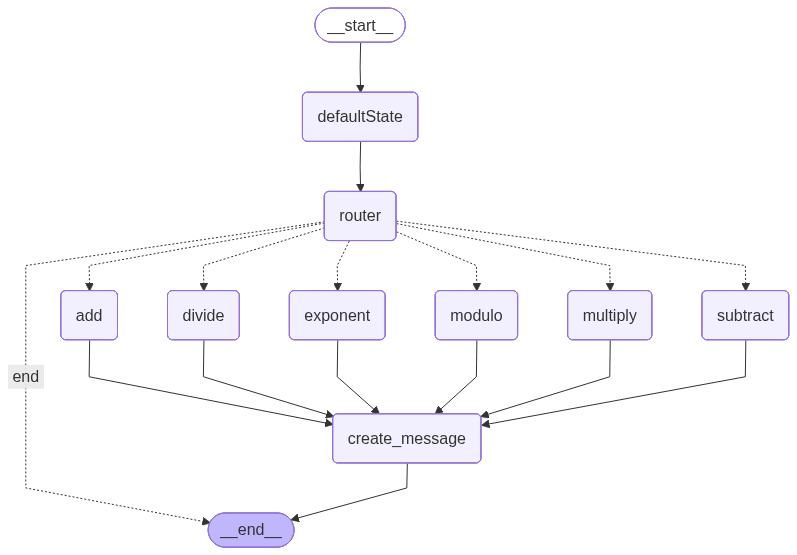

In [5]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
result = graph.invoke({'num1': 10, 'operator': '+', 'num2': 5})
print(result['message'])

10 + 5 = 15
